In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import conf_file as conf
import EKF

# loading the data
ground_truth  = np.loadtxt("data/ground_truth_3d_position.csv", delimiter=",", skiprows=1)
camera_sensor = np.loadtxt("data/measurements_2d_camera.csv", delimiter=",", skiprows=1)

# Plot of raw measurements

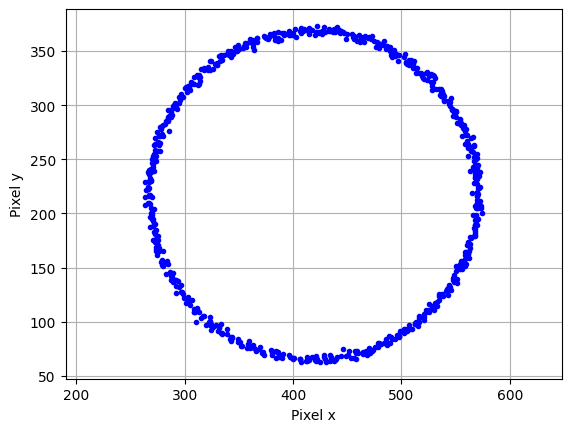

In [2]:
# plot of camera image
plt.figure()
plt.plot(camera_sensor[:,0], camera_sensor[:,1], '.', color='blue')
plt.xlabel("Pixel x")
plt.ylabel("Pixel y")
plt.axis('equal')
plt.grid()
plt.show()


# EKF with 2D camera
### Initial conditions A

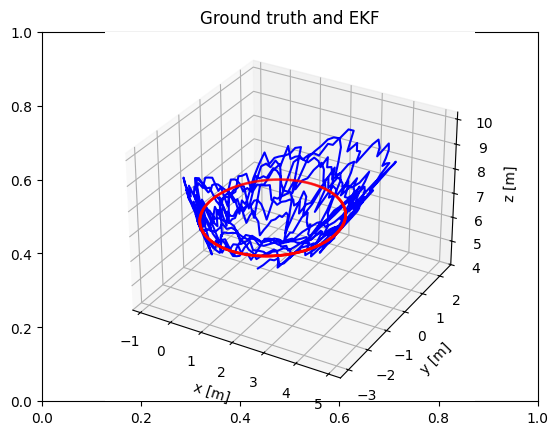

In [3]:
# Kalman filter
P = np.eye(conf.nx)
x = np.array([-0.7, -0.3, 6.6, 0, 0, 0])
x_EKF_A = np.zeros((np.size(camera_sensor[:,0]), conf.nx))
for i in range(np.size(camera_sensor[:,0])):
    # prediction step
    x, P = EKF.prediction(x, conf.A2, P, conf.Q2)
    # update step
    x, P = EKF.update(x, camera_sensor[i,:], conf.h2, conf.H2, P, conf.R2, conf.nx)
    # storing the result
    x_EKF_A[i, :] = x

# 3D plot
fig = plt.figure()
plt.title("Ground truth and EKF")
ax = fig.add_subplot(111, projection="3d")
ax.scatter(ground_truth[:,0],ground_truth[:,1],ground_truth[:,2], s=1, color='red')
ax.plot(x_EKF_A[:,0],x_EKF_A[:,1],x_EKF_A[:,2], color='blue')
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
plt.show()

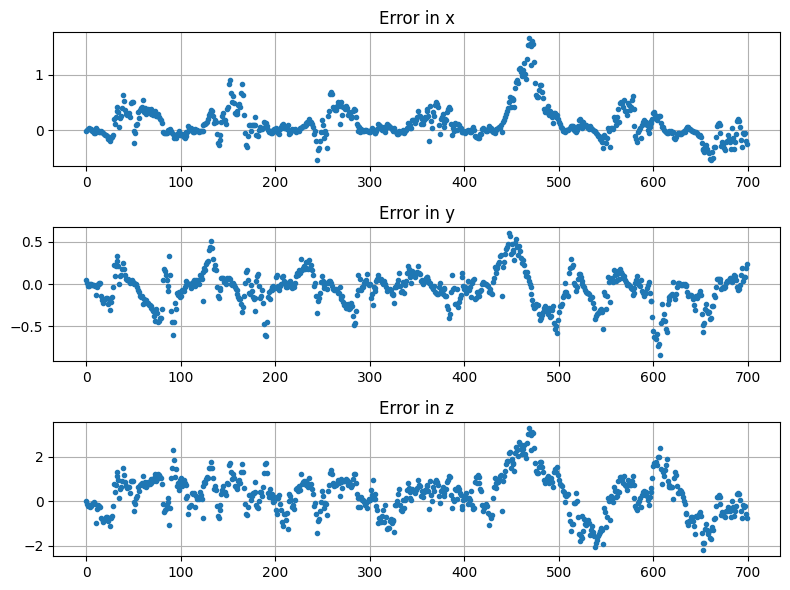

In [4]:
# plot of the estimation error
fig, ax = plt.subplots(3, 1, figsize=(8, 6))

ax[0].plot(x_EKF_A[:,0]-ground_truth[:,0],'.')
ax[0].set_title("Error in x")
ax[0].grid()

ax[1].plot(x_EKF_A[:,1]-ground_truth[:,1],'.')
ax[1].set_title("Error in y")
ax[1].grid()

ax[2].plot(x_EKF_A[:,2]-ground_truth[:,2],'.')
ax[2].set_title("Error in z")
ax[2].grid()

plt.tight_layout()
plt.show()

### Initial conditions B

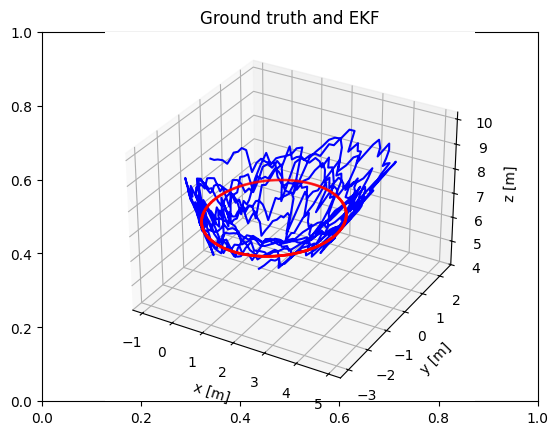

In [5]:
# Kalman filter
P = np.eye(conf.nx)
x = np.array([-1.8, -0.5, 7.9, 0, 0, 0])
x_EKF_B = np.zeros((np.size(camera_sensor[:,0]), conf.nx))
for i in range(np.size(camera_sensor[:,0])):
    # prediction step
    x, P = EKF.prediction(x, conf.A2, P, conf.Q2)
    # update step
    x, P = EKF.update(x, camera_sensor[i,:], conf.h2, conf.H2, P, conf.R2, conf.nx)
    # storing the result
    x_EKF_B[i, :] = x

# 3D plot
fig = plt.figure()
plt.title("Ground truth and EKF")
ax = fig.add_subplot(111, projection="3d")
ax.scatter(ground_truth[:,0],ground_truth[:,1],ground_truth[:,2], s=1, color='red')
ax.plot(x_EKF_B[:,0],x_EKF_B[:,1],x_EKF_B[:,2], color='blue')
ax.set_xlabel("x [m]")
ax.set_ylabel("y [m]")
ax.set_zlabel("z [m]")
plt.show()

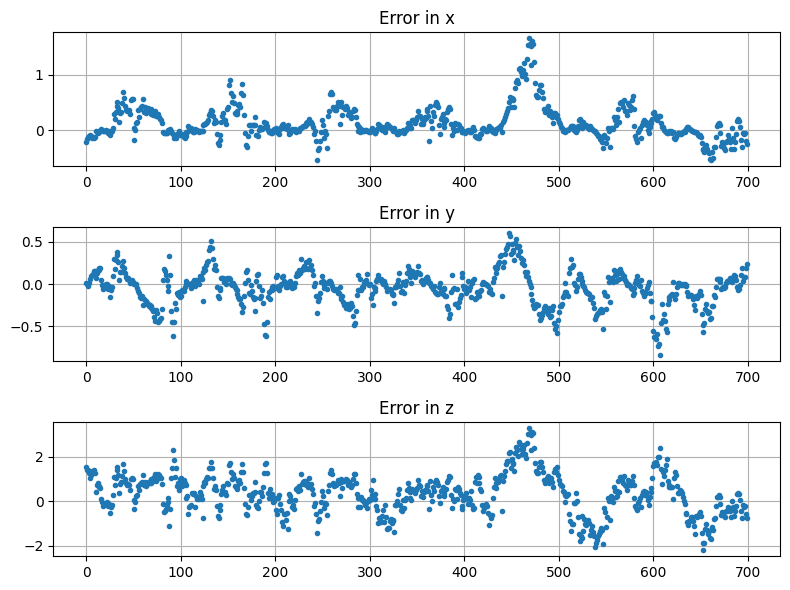

In [6]:
# plot of the estimation error
fig, ax = plt.subplots(3, 1, figsize=(8, 6))

ax[0].plot(x_EKF_B[:,0]-ground_truth[:,0],'.')
ax[0].set_title("Error in x")
ax[0].grid()

ax[1].plot(x_EKF_B[:,1]-ground_truth[:,1],'.')
ax[1].set_title("Error in y")
ax[1].grid()

ax[2].plot(x_EKF_B[:,2]-ground_truth[:,2],'.')
ax[2].set_title("Error in z")
ax[2].grid()

plt.tight_layout()
plt.show()